In [1]:
import pandas as pd
import numpy as np
import sklearn
import os

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from ucimlrepo import fetch_ucirepo

# fetch dataset
adult = fetch_ucirepo(id=2)

# data (as pandas dataframes)
X_raw = adult.data.features
y_raw = adult.data.targets

In [2]:
X_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             48842 non-null  int64
 1   workclass       47879 non-null  str  
 2   fnlwgt          48842 non-null  int64
 3   education       48842 non-null  str  
 4   education-num   48842 non-null  int64
 5   marital-status  48842 non-null  str  
 6   occupation      47876 non-null  str  
 7   relationship    48842 non-null  str  
 8   race            48842 non-null  str  
 9   sex             48842 non-null  str  
 10  capital-gain    48842 non-null  int64
 11  capital-loss    48842 non-null  int64
 12  hours-per-week  48842 non-null  int64
 13  native-country  48568 non-null  str  
dtypes: int64(6), str(8)
memory usage: 5.2 MB


In [3]:
X_raw.describe(include='all')

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
count,48842.000000,47879,4.884200e+04,48842,48842.000000,48842,47876,48842,48842,48842,48842.000000,48842.000000,48842.000000,48568
unique,NaN,9,NaN,16,NaN,7,15,6,5,2,NaN,NaN,NaN,42
top,NaN,Private,NaN,HS-grad,NaN,Married-civ-spouse,Prof-specialty,Husband,White,Male,NaN,NaN,NaN,United-States
freq,NaN,33906,NaN,15784,NaN,22379,6172,19716,41762,32650,NaN,NaN,NaN,43832
mean,38.643585,NaN,1.896641e+05,NaN,10.078089,NaN,NaN,NaN,NaN,NaN,1079.067626,87.502314,40.422382,NaN
std,13.710510,NaN,1.056040e+05,NaN,2.570973,NaN,NaN,NaN,NaN,NaN,7452.019058,403.004552,12.391444,NaN
min,17.000000,NaN,1.228500e+04,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,1.000000,NaN
25%,28.000000,NaN,1.175505e+05,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN
50%,37.000000,NaN,1.781445e+05,NaN,10.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN
75%,48.000000,NaN,2.376420e+05,NaN,12.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,45.000000,NaN


In [4]:
y_raw.value_counts()

income
<=50K     24720
<=50K.    12435
>50K       7841
>50K.      3846
Name: count, dtype: int64

In [5]:
X_raw.isna().sum()

age                 0
workclass         963
fnlwgt              0
education           0
education-num       0
marital-status      0
occupation        966
relationship        0
race                0
sex                 0
capital-gain        0
capital-loss        0
hours-per-week      0
native-country    274
dtype: int64

In [6]:
X_raw['workclass'].value_counts()

workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
State-gov            1981
?                    1836
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64

In [7]:
X_raw['occupation'].value_counts()

occupation
Prof-specialty       6172
Craft-repair         6112
Exec-managerial      6086
Adm-clerical         5611
Sales                5504
Other-service        4923
Machine-op-inspct    3022
Transport-moving     2355
Handlers-cleaners    2072
?                    1843
Farming-fishing      1490
Tech-support         1446
Protective-serv       983
Priv-house-serv       242
Armed-Forces           15
Name: count, dtype: int64

In [8]:
X_raw['native-country'].value_counts()

native-country
United-States                 43832
Mexico                          951
?                               583
Philippines                     295
Germany                         206
Puerto-Rico                     184
Canada                          182
El-Salvador                     155
India                           151
Cuba                            138
England                         127
China                           122
South                           115
Jamaica                         106
Italy                           105
Dominican-Republic              103
Japan                            92
Guatemala                        88
Poland                           87
Vietnam                          86
Columbia                         85
Haiti                            75
Portugal                         67
Taiwan                           65
Iran                             59
Greece                           49
Nicaragua                        49
Peru         

In [9]:
X_raw.groupby('education')['education-num'].nunique()
#Bekræfter at den ene er overflødig.

education
10th            1
11th            1
12th            1
1st-4th         1
5th-6th         1
7th-8th         1
9th             1
Assoc-acdm      1
Assoc-voc       1
Bachelors       1
Doctorate       1
HS-grad         1
Masters         1
Preschool       1
Prof-school     1
Some-college    1
Name: education-num, dtype: int64

array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'fnlwgt'}>],
       [<Axes: title={'center': 'education-num'}>,
        <Axes: title={'center': 'capital-gain'}>],
       [<Axes: title={'center': 'capital-loss'}>,
        <Axes: title={'center': 'hours-per-week'}>]], dtype=object)

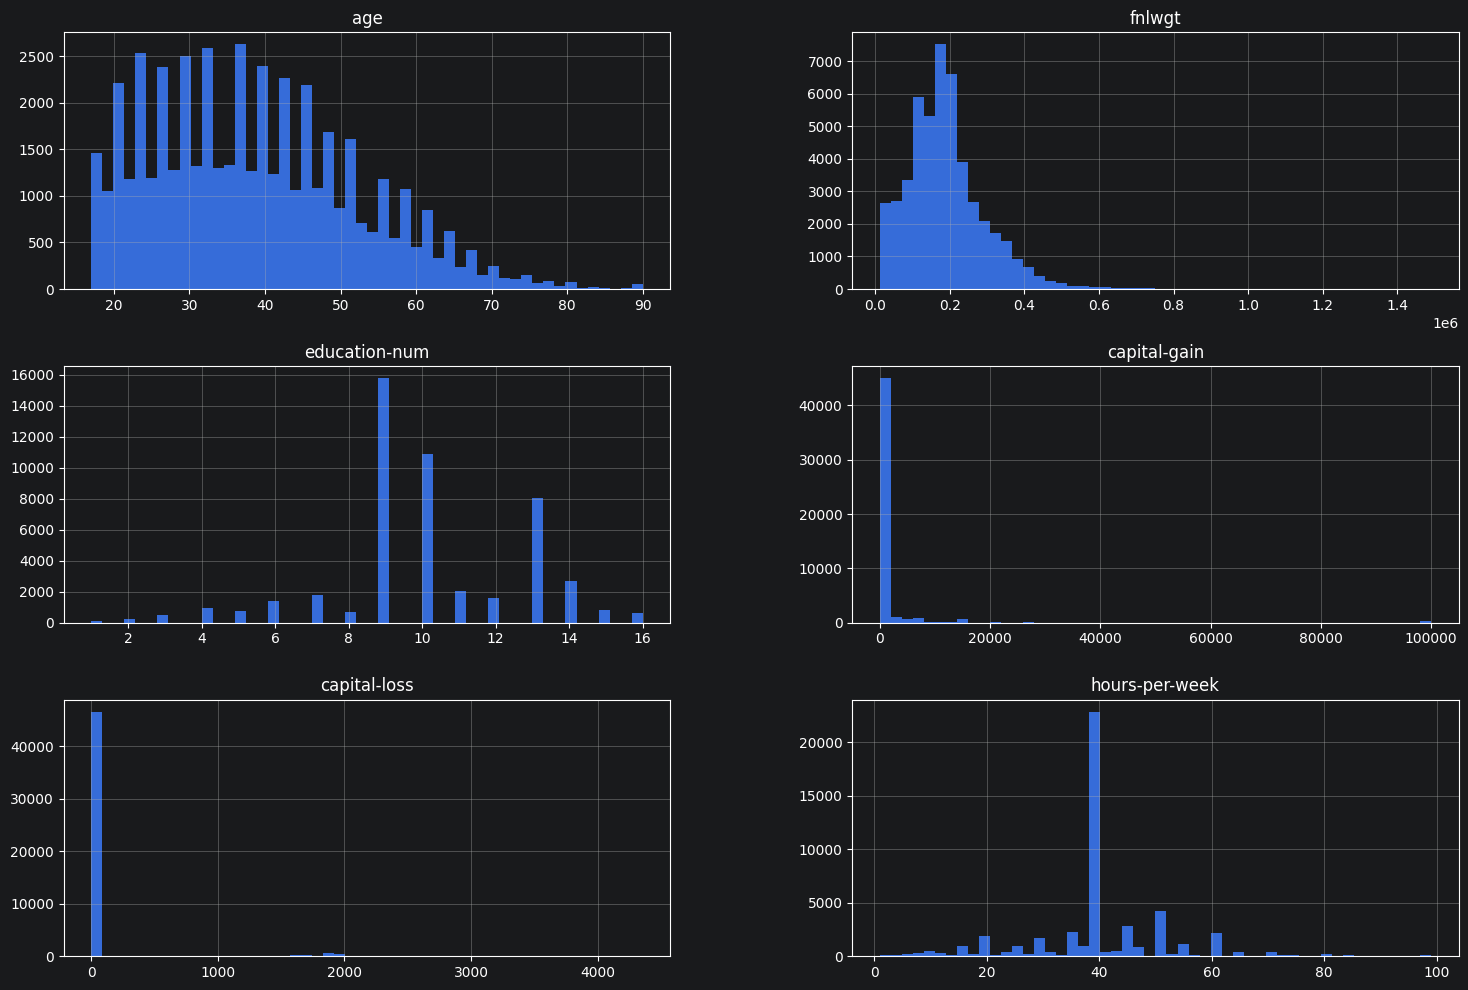

In [10]:
X_raw.hist(bins=50, figsize=(18,12))

<Axes: >

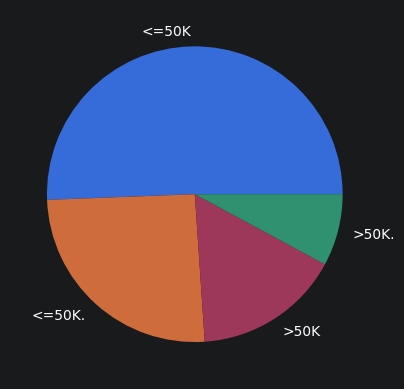

In [11]:
count = y_raw['income'].value_counts()
count.plot(kind='pie')#Der er 4 target kategorier

In [12]:
#Target har 4 kategorier, så vi fjerner de to med trailing . og samler dem.
y_clean = y_raw['income'].str.strip().str.rstrip('.')
y_clean.value_counts()

income
<=50K    37155
>50K     11687
Name: count, dtype: int64

In [13]:
#Vi laver ? om til NaN, fordi det ellers ville blive til en kategori når vi skal ohe det senere, hvilket ville
#være misvisende
X_clean = X_raw.replace('?', np.nan)
X_clean.isna().sum()
#Før havde vi både ? og NaN, de er nu alle NaN

X_clean = X_clean.drop(columns=['education'])
X_clean = X_clean.dropna()
y_clean = y_clean.loc[X_clean.index]

#grupper landende så vi har 10 ialt, da USA dominerer så meget.
top10_countries = X_clean['native-country'].value_counts().head(9).index #tager index op de 9 største lande
X_clean['native-country'] = X_clean['native-country'].where(X_clean['native-country'].isin(top10_countries), 'Other')
X_clean['native-country'].value_counts()

native-country
United-States    41292
Other             1786
Mexico             903
Philippines        283
Germany            193
Puerto-Rico        175
Canada             163
India              147
El-Salvador        147
Cuba               133
Name: count, dtype: int64

In [14]:
from sklearn.model_selection import train_test_split

#Vi splitter i tre sæt så vi har train til at fitte modellen, val til at fintune og test til at teste til sidst.
X_train_full, X_test, y_train_full, y_test = train_test_split(X_clean, y_clean, test_size=0.2, random_state=42, stratify=y_clean)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full)

In [15]:
#Stratify opdeler labels i lige store propertioner.
print(X_train.shape, X_val.shape, X_test.shape)
#normalize=true giver fordeling
print(y_train.value_counts(normalize=True))
print(y_val.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(28941, 13) (7236, 13) (9045, 13)
income
<=50K    0.752151
>50K     0.247849
Name: proportion, dtype: float64
income
<=50K    0.752211
>50K     0.247789
Name: proportion, dtype: float64
income
<=50K    0.752128
>50K     0.247872
Name: proportion, dtype: float64


In [16]:
X_clean.isna().any(axis=1).sum()
len(X_clean.dropna())

45222

In [17]:
#Encode
from sklearn.compose import ColumnTransformer
col_cat = ['workclass', 'occupation', 'marital-status', 'relationship', 'race', 'sex', 'native-country']
col_num = ['age', 'fnlwgt', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss']

preprocesser = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='if_binary'), col_cat)
    ,('num', StandardScaler(), col_num)
])

#drop=if-binary betyder at hvis featuren kun har 2 unike værdier ligesom sex,
#så dropper vi den ene kolonne, men dem med 3+ sker der ikke noget ved. De er redundante fordi er de perfekt anti correlated.

X_train = preprocesser.fit_transform(X_train)
X_val = preprocesser.transform(X_val)
X_test = preprocesser.transform(X_test)



In [18]:
import keras
import keras.metrics as km

model = keras.models.Sequential([
    #hidden layers
    keras.layers.Dense(100, activation='relu'),
    keras.layers.Dense(100, activation='relu'),
    keras.layers.Dense(100, activation='relu'),
    keras.layers.Dense(100, activation='relu'),
    #output layer
    keras.layers.Dense(1, activation='sigmoid')])

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=[
        keras.metrics.Recall(),
        keras.metrics.Precision(),
        keras.metrics.F1Score(threshold=0.5, name='f1'),
        keras.metrics.AUC()
    ])

y_train_binary = (y_train == '>50K').astype(int)
y_val_binary = (y_val == '>50K').astype(int)
y_test_binary = (y_test == '>50K').astype(int)


In [23]:
#Callbacks
es_cb = keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)

In [24]:
history = model.fit(
    X_train, y_train_binary,
    validation_data=(X_val, y_val_binary),
    epochs=20,
    batch_size=32,
    callbacks=[es_cb],
)

Epoch 1/20
905/905 ━━━━━━━━━━━━━━━━━━━━ 1s 667us/step - auc: 0.9002 - f1: 0.6547 - loss: 0.3316 - precision: 0.7313 - recall: 0.5926 - val_auc: 0.9129 - val_f1: 0.6818 - val_loss: 0.3168 - val_precision: 0.7473 - val_recall: 0.6269
Epoch 2/20
905/905 ━━━━━━━━━━━━━━━━━━━━ 0s 518us/step - auc: 0.9106 - f1: 0.6759 - loss: 0.3164 - precision: 0.7514 - recall: 0.6142 - val_auc: 0.9155 - val_f1: 0.6963 - val_loss: 0.3087 - val_precision: 0.7435 - val_recall: 0.6548
Epoch 3/20
905/905 ━━━━━━━━━━━━━━━━━━━━ 0s 496us/step - auc: 0.9136 - f1: 0.6820 - loss: 0.3109 - precision: 0.7583 - recall: 0.6197 - val_auc: 0.9149 - val_f1: 0.6767 - val_loss: 0.3081 - val_precision: 0.7952 - val_recall: 0.5890
Epoch 4/20
905/905 ━━━━━━━━━━━━━━━━━━━━ 0s 526us/step - auc: 0.9157 - f1: 0.6843 - loss: 0.3072 - precision: 0.7613 - recall: 0.6215 - val_auc: 0.9146 - val_f1: 0.6829 - val_loss: 0.3114 - val_precision: 0.7649 - val_recall: 0.6168
Epoch 5/20
905/905 ━━━━━━━━━━━━━━━━━━━━ 0s 499us/step - auc: 0.9178 - f1

In [25]:
results = model.evaluate(X_test, y_test_binary, return_dict=True)
for name, value in results.items():
    print(f"{name:10s}: {float(np.asarray(value).flatten()[0]):.4f}")

283/283 ━━━━━━━━━━━━━━━━━━━━ 0s 322us/step - auc: 0.9084 - f1: 0.6546 - loss: 0.3220 - precision: 0.7753 - recall: 0.5665
auc       : 0.9084
f1        : 0.6546
loss      : 0.3220
precision : 0.7753
recall    : 0.5665
